# Task 2: Vision Task - Improved CNN and Transfer Learning Notebook


In [1]:
# Import necessary libraries
import os
import random
import time
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization,
    Rescaling, GlobalAveragePooling2D
)

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_recall_fscore_support
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:

import os
import zipfile
import shutil
from pathlib import Path
from sklearn.model_selection import train_test_split

from google.colab import drive
drive.mount("/content/drive")

ZIP_PATH = "/content/drive/MyDrive/college/sem6/AI&ML/Assessment/Vision Task /FacialExpressionDetection.zip"

EXTRACT_PATH = Path("/content/facial_expressions_dataset")
SPLIT_OUTPUT_PATH = Path("/content/facial_expressions_dataset_split")

RANDOM_SEED = 42
TEST_SIZE_FROM_VALIDATION = 0.50


if EXTRACT_PATH.exists():
    shutil.rmtree(EXTRACT_PATH)

EXTRACT_PATH.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Extracted dataset to:", EXTRACT_PATH)


candidate_roots = []

for root, dirs, files in os.walk(EXTRACT_PATH):
    dirs_lower = [d.lower() for d in dirs]

    if "train" in dirs_lower and "validation" in dirs_lower:
        candidate_roots.append(Path(root))

if len(candidate_roots) == 0:
    raise FileNotFoundError(
        "Could not find a dataset folder containing both 'train' and 'validation' folders. "
        "Please check the ZIP folder structure."
    )

DATA_ROOT = candidate_roots[0]

print("Detected dataset root:", DATA_ROOT)

ORIGINAL_TRAIN_DIR = DATA_ROOT / "train"
ORIGINAL_VALIDATION_DIR = DATA_ROOT / "validation"

print("Original train folder:", ORIGINAL_TRAIN_DIR)
print("Original validation folder:", ORIGINAL_VALIDATION_DIR)

# Create Split folders

if SPLIT_OUTPUT_PATH.exists():
    shutil.rmtree(SPLIT_OUTPUT_PATH)

train_data_dir = SPLIT_OUTPUT_PATH / "train"
validation_data_dir = SPLIT_OUTPUT_PATH / "validation"
test_data_dir = SPLIT_OUTPUT_PATH / "test"

# Copy original train folder unchanged
shutil.copytree(ORIGINAL_TRAIN_DIR, train_data_dir)

# Get class names from train folder
class_names = sorted([
    folder.name for folder in train_data_dir.iterdir()
    if folder.is_dir()
])

print("Detected classes:", class_names)

for class_name in class_names:
    (validation_data_dir / class_name).mkdir(parents=True, exist_ok=True)
    (test_data_dir / class_name).mkdir(parents=True, exist_ok=True)


valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

for class_name in class_names:
    source_class_dir = ORIGINAL_VALIDATION_DIR / class_name

    if not source_class_dir.exists():
        raise FileNotFoundError(f"Missing validation class folder: {source_class_dir}")

    image_paths = [
        path for path in source_class_dir.iterdir()
        if path.suffix.lower() in valid_extensions
    ]

    if len(image_paths) < 2:
        raise ValueError(
            f"Not enough images in validation class '{class_name}' to split into validation and test."
        )

    val_paths, test_paths = train_test_split(
        image_paths,
        test_size=TEST_SIZE_FROM_VALIDATION,
        random_state=RANDOM_SEED,
        shuffle=True
    )

    for path in val_paths:
        shutil.copy2(path, validation_data_dir / class_name / path.name)

    for path in test_paths:
        shutil.copy2(path, test_data_dir / class_name / path.name)

print("Created new train, validation and test split at:", SPLIT_OUTPUT_PATH)

#Check split count
def count_images_by_class(directory):
    directory = Path(directory)
    counts = {}

    for class_name in class_names:
        class_dir = directory / class_name
        counts[class_name] = len([
            path for path in class_dir.iterdir()
            if path.suffix.lower() in valid_extensions
        ])

    return counts

print("\nFinal train counts:")
print(count_images_by_class(train_data_dir))

print("\nFinal validation counts:")
print(count_images_by_class(validation_data_dir))

print("\nFinal test counts:")
print(count_images_by_class(test_data_dir))

print("\nFinal dataset paths:")
print("train_data_dir:", train_data_dir)
print("validation_data_dir:", validation_data_dir)
print("test_data_dir:", test_data_dir)

# Convert Path objects to strings for Keras ImageDataGenerator
train_data_dir = str(train_data_dir)
validation_data_dir = str(validation_data_dir)
test_data_dir = str(test_data_dir)

Mounted at /content/drive
Extracted dataset to: /content/facial_expressions_dataset
Detected dataset root: /content/facial_expressions_dataset/images
Original train folder: /content/facial_expressions_dataset/images/train
Original validation folder: /content/facial_expressions_dataset/images/validation
Detected classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Created new train, validation and test split at: /content/facial_expressions_dataset_split

Final train counts:
{'angry': 3993, 'disgust': 436, 'fear': 4103, 'happy': 7164, 'neutral': 4982, 'sad': 4938, 'surprise': 3205}

Final validation counts:
{'angry': 480, 'disgust': 55, 'fear': 509, 'happy': 912, 'neutral': 608, 'sad': 569, 'surprise': 398}

Final test counts:
{'angry': 480, 'disgust': 56, 'fear': 509, 'happy': 913, 'neutral': 608, 'sad': 570, 'surprise': 399}

Final dataset paths:
train_data_dir: /content/facial_expressions_dataset_split/train
validation_data_dir: /content/facial_expressions_data

## Dataset understanding and cleaning

The images are grayscale facial-expression images. The classes are expected to represent emotions such as angry, disgust, fear, happy, neutral, sad and surprise. The cells below check the number of images, class balance and corrupted image files before model training.

In [3]:
#Dataset cleaning
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".gif")

def count_images_by_class(data_dir):
    counts = {}
    for class_name in sorted(os.listdir(data_dir)):
        class_path = os.path.join(data_dir, class_name)
        if os.path.isdir(class_path):
            counts[class_name] = len([
                f for f in os.listdir(class_path)
                if f.lower().endswith(IMAGE_EXTENSIONS)
            ])
    return counts

def count_total_images(root_dir):
    total = 0
    for split in ["train", "validation", "test"]:
        split_dir = os.path.join(root_dir, split)
        if os.path.exists(split_dir):
            total += sum(count_images_by_class(split_dir).values())
    return total

def find_bad_images(root_dir):
    bad_files = []
    for dirpath, _, filenames in os.walk(root_dir):
        for fname in filenames:
            if fname.lower().endswith(IMAGE_EXTENSIONS):
                fpath = os.path.join(dirpath, fname)
                try:
                    with Image.open(fpath) as img:
                        img.verify()
                except Exception as e:
                    bad_files.append((fpath, str(e)))
    return pd.DataFrame(bad_files, columns=["file_path", "error"])

def remove_bad_images(bad_df):
    removed = 0
    for path in bad_df["file_path"]:
        if os.path.exists(path):
            os.remove(path)
            removed += 1
    return removed

print("Total images before cleaning:", count_total_images(DATA_ROOT))

bad_train = find_bad_images(train_data_dir)
bad_val = find_bad_images(validation_data_dir)
bad_test = find_bad_images(test_data_dir)

print("Bad train images:", len(bad_train))
print("Bad validation images:", len(bad_val))
print("Bad test images:", len(bad_test))

removed = remove_bad_images(bad_train) + remove_bad_images(bad_val) + remove_bad_images(bad_test)
print("Removed corrupted images:", removed)
print("Total images after cleaning:", count_total_images(DATA_ROOT))

Total images before cleaning: 35887
Bad train images: 0
Bad validation images: 0
Bad test images: 0
Removed corrupted images: 0
Total images after cleaning: 35887


,train,validation,test
angry,3993,480,480
disgust,436,55,56
fear,4103,509,509
happy,7164,912,913
neutral,4982,608,608
sad,4938,569,570
surprise,3205,398,399
TOTAL,28821,3531,3535


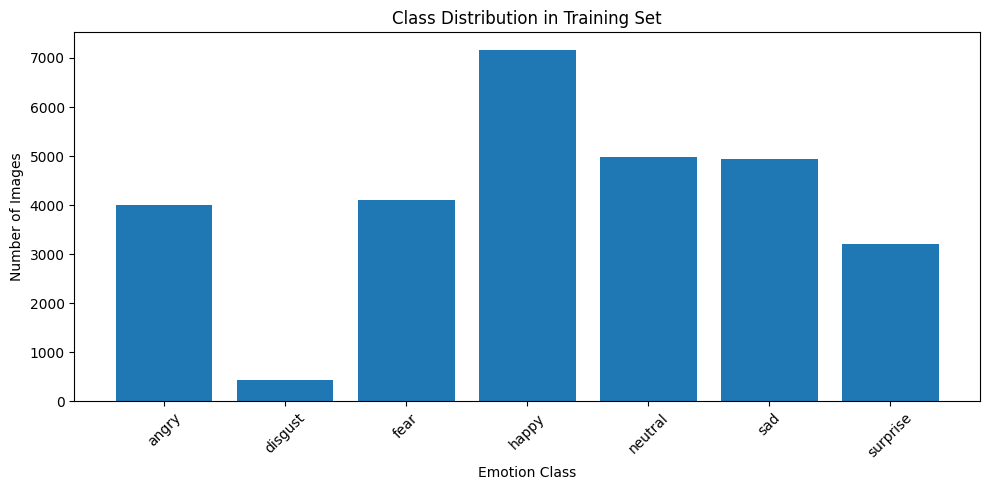

In [4]:
# Checking class Distribution
train_class_counts = count_images_by_class(train_data_dir)
val_class_counts = count_images_by_class(validation_data_dir)
test_class_counts = count_images_by_class(test_data_dir)

distribution_df = pd.DataFrame({
    "train": train_class_counts,
    "validation": val_class_counts,
    "test": test_class_counts
}).fillna(0).astype(int)

distribution_df.loc["TOTAL"] = distribution_df.sum(axis=0)
display(distribution_df)

plt.figure(figsize=(10, 5))
plt.bar(train_class_counts.keys(), train_class_counts.values())
plt.title("Class Distribution in Training Set")
plt.xlabel("Emotion Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

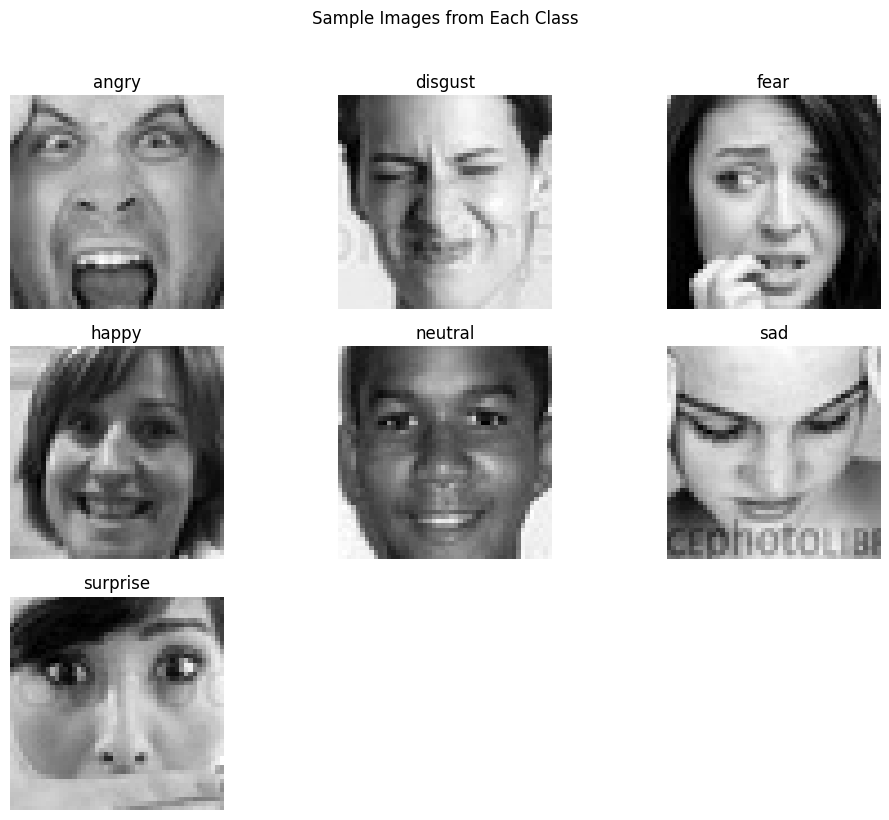

In [5]:
# Visualize one sample per class
plt.figure(figsize=(10, 8))
for i, class_name in enumerate(sorted(os.listdir(train_data_dir)), start=1):
    class_path = os.path.join(train_data_dir, class_name)
    if not os.path.isdir(class_path):
        continue

    image_files = [f for f in os.listdir(class_path) if f.lower().endswith(IMAGE_EXTENSIONS)]
    if len(image_files) == 0:
        continue

    img_path = os.path.join(class_path, random.choice(image_files))
    img = Image.open(img_path)

    plt.subplot(3, 3, i)
    plt.imshow(img, cmap="gray")
    plt.title(class_name)
    plt.axis("off")

plt.suptitle("Sample Images from Each Class", y=1.02)
plt.tight_layout()
plt.show()

## Preprocessing and augmentation



In [6]:

IMG_SIZE = (48, 48)
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

train_raw = tf.keras.utils.image_dataset_from_directory(
    train_data_dir,
    image_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True,
    seed=SEED
)

val_raw = tf.keras.utils.image_dataset_from_directory(
    validation_data_dir,
    image_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

test_raw = tf.keras.utils.image_dataset_from_directory(
    test_data_dir,
    image_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

class_names = train_raw.class_names
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)

# Save labels before applying cache/shuffle/prefetch.
y_train_flat = np.concatenate([labels.numpy() for _, labels in train_raw], axis=0)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=y_train_flat
)

# Smoothing prevents the rarest class from dominating training too strongly.
smoothed_class_weights_array = np.sqrt(class_weights_array)
class_weights = dict(enumerate(smoothed_class_weights_array))

print("Smoothed class weights:")
for i, weight in class_weights.items():
    print(f"{class_names[i]}: {weight:.4f}")

train_ds = train_raw.cache().shuffle(2000, seed=SEED).prefetch(AUTOTUNE)
val_ds = val_raw.cache().prefetch(AUTOTUNE)
test_ds = test_raw.cache().prefetch(AUTOTUNE)

Found 28821 files belonging to 7 classes.
Found 3531 files belonging to 7 classes.
Found 3535 files belonging to 7 classes.
Class names: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Number of classes: 7
Smoothed class weights:
angry: 1.0154
disgust: 3.0730
fear: 1.0017
happy: 0.7581
neutral: 0.9091
sad: 0.9131
surprise: 1.1334


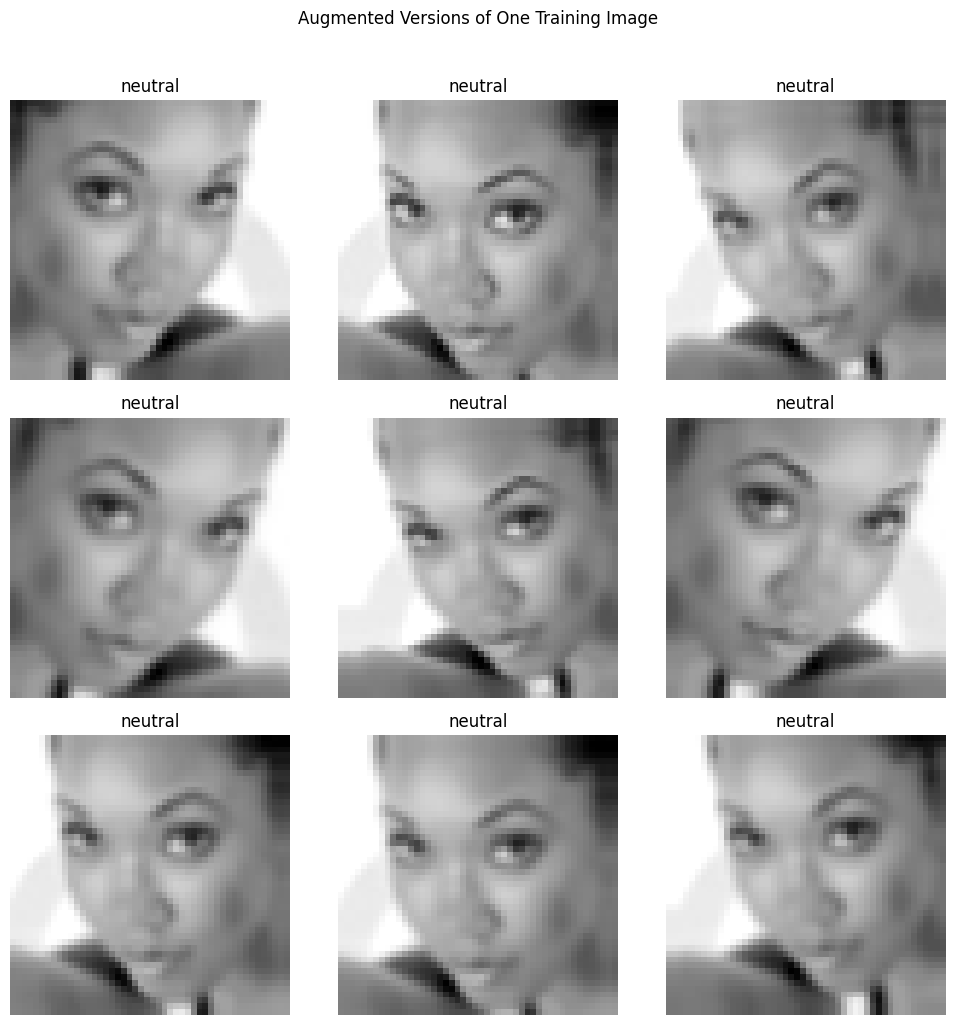

In [7]:
# Visualize data augmentation
data_augmentation = Sequential([
    layers.RandomFlip("horizontal", seed=SEED),
    layers.RandomRotation(0.04, seed=SEED),
    layers.RandomZoom(0.08, seed=SEED),
    layers.RandomTranslation(0.04, 0.04, seed=SEED),
    layers.RandomContrast(0.10, seed=SEED),
], name="mild_data_augmentation")

for images, labels in train_ds.take(1):
    first_image = images[0]

    plt.figure(figsize=(10, 10))
    for i in range(9):
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0), training=True)
        plt.subplot(3, 3, i + 1)
        plt.imshow(tf.squeeze(augmented_image[0]), cmap="gray")
        plt.title(class_names[int(labels[0])])
        plt.axis("off")

    plt.suptitle("Augmented Versions of One Training Image", y=1.02)
    plt.tight_layout()
    plt.show()

In [8]:
# Evaluation & plotting functions
def plot_history(history, title_prefix):
    hist = pd.DataFrame(history.history)

    plt.figure(figsize=(9, 5))
    plt.plot(hist["loss"], label="Training Loss")
    plt.plot(hist["val_loss"], label="Validation Loss")
    plt.title(f"{title_prefix}: Training vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    if "accuracy" in hist.columns:
        plt.figure(figsize=(9, 5))
        plt.plot(hist["accuracy"], label="Training Accuracy")
        plt.plot(hist["val_accuracy"], label="Validation Accuracy")
        plt.title(f"{title_prefix}: Training vs Validation Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

def get_true_labels(dataset):
    return np.concatenate([labels.numpy() for _, labels in dataset], axis=0)

def evaluate_model(model, dataset, class_names, model_name):
    y_true = get_true_labels(dataset)
    y_prob = model.predict(dataset, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    loss, accuracy = model.evaluate(dataset, verbose=0)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    print(f"\n{model_name} Evaluation")
    print("-" * 60)
    print(f"Test loss: {loss:.4f}")
    print(f"Test accuracy: {accuracy:.4f}")
    print(f"Weighted precision: {precision:.4f}")
    print(f"Weighted recall: {recall:.4f}")
    print(f"Weighted F1-score: {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(9, 7))
    disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
    plt.title(f"{model_name}: Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return {
        "Model": model_name,
        "Test Loss": loss,
        "Test Accuracy": accuracy,
        "Weighted Precision": precision,
        "Weighted Recall": recall,
        "Weighted F1": f1
    }, y_true, y_pred, y_prob

def plot_sample_predictions(model, dataset, class_names, title, n=9):
    all_images = []
    all_labels = []

    for images, labels in dataset:
        all_images.append(images.numpy())
        all_labels.append(labels.numpy())

    all_images = np.concatenate(all_images, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    sample_indices = np.random.choice(
        len(all_images),
        size=min(n, len(all_images)),
        replace=False
    )

    sample_images = all_images[sample_indices]
    sample_labels = all_labels[sample_indices]

    probabilities = model.predict(sample_images, verbose=0)
    predictions = np.argmax(probabilities, axis=1)

    plt.figure(figsize=(12, 10))

    for plot_i, idx in enumerate(range(len(sample_images)), start=1):
        image = sample_images[idx]

        plt.subplot(3, 3, plot_i)

        if image.shape[-1] == 1:
            display_image = np.squeeze(image)

            if display_image.max() > 1:
                display_image = display_image / 255.0

            plt.imshow(display_image, cmap="gray")

        else:
            display_image = image.copy()

            if display_image.max() > 1:
                display_image = display_image / 255.0

            display_image = np.clip(display_image, 0, 1)
            plt.imshow(display_image)

        true_label = class_names[int(sample_labels[idx])]
        pred_label = class_names[int(predictions[idx])]
        confidence = np.max(probabilities[idx])

        color = "green" if true_label == pred_label else "red"

        plt.title(
            f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.2f}",
            color=color
        )
        plt.axis("off")

    plt.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

def make_callbacks(prefix, monitor="val_loss", mode="min", patience=8):
    return [
        ModelCheckpoint(
            f"{prefix}_best.keras",
            monitor=monitor,
            save_best_only=True,
            mode=mode,
            verbose=1
        ),
        EarlyStopping(
            monitor=monitor,
            patience=patience,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor=monitor,
            factor=0.3,
            patience=3,
            min_lr=1e-6,
            verbose=1
        )
    ]

# Part A: CNN models from scratch

## Baseline CNN


In [9]:
# Baseline CNN model
def build_baseline_model():
    model = Sequential([
        layers.Input(shape=(48, 48, 1)),
        data_augmentation,
        Rescaling(1./255),

        Conv2D(32, (3, 3), activation="relu", padding="same"),
        MaxPooling2D((2, 2)),

        Conv2D(64, (3, 3), activation="relu", padding="same"),
        MaxPooling2D((2, 2)),

        Conv2D(128, (3, 3), activation="relu", padding="same"),
        MaxPooling2D((2, 2)),

        Flatten(),

        Dense(256, activation="relu"),
        Dropout(0.30),
        Dense(128, activation="relu"),
        Dropout(0.20),
        Dense(64, activation="relu"),

        Dense(num_classes, activation="softmax")
    ], name="baseline_cnn")

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

baseline_model = build_baseline_model()
baseline_model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mild_data_augmentation          │ (None, 48, 48, 1)      │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,314,183 (5.01 MB)

 Trainable params: 1,314,183 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Train baseline model
BASELINE_EPOCHS = 30

start_time = time.time()
baseline_history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=BASELINE_EPOCHS,
    class_weight=class_weights,
    callbacks=make_callbacks("baseline", monitor="val_loss", mode="min", patience=8),
    verbose=1
)
baseline_training_time = time.time() - start_time

print(f"Baseline training time: {baseline_training_time:.2f} seconds")

Epoch 1/30
448/451 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2126 - loss: 1.8238
Epoch 1: val_loss improved from None to 1.76356, saving model to baseline_best.keras

Epoch 1: finished saving model to baseline_best.keras
451/451 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.2323 - loss: 1.8040 - val_accuracy: 0.2880 - val_loss: 1.7636 - learning_rate: 0.0010
Epoch 2/30
448/451 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2931 - loss: 1.7151
Epoch 2: val_loss improved from 1.76356 to 1.57831, saving model to baseline_best.keras

Epoch 2: finished saving model to baseline_best.keras
451/451 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.3132 - loss: 1.6849 - val_accuracy: 0.3920 - val_loss: 1.5783 - learning_rate: 0.0010
Epoch 3/30
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3753 - loss: 1.5844
Epoch 3: val_loss improved from 1.57831 to 1.48397, saving model to baseline_best.keras

Epoch 3: finished saving model to baseline_best.keras
451/451 ━━━━━━━━━━━━━━━━━━━━

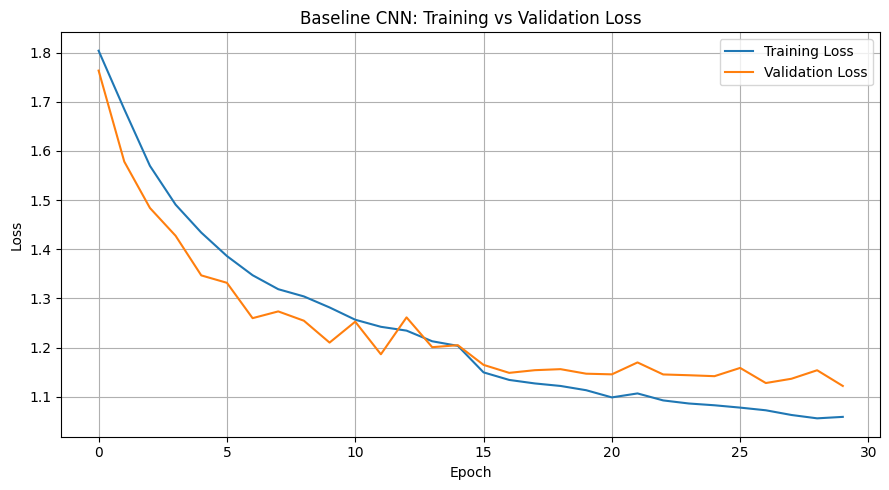

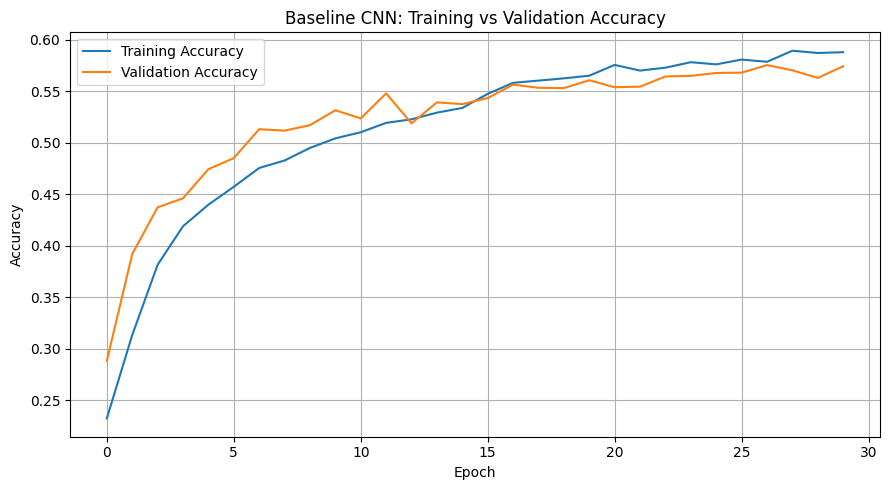


Baseline CNN Evaluation
------------------------------------------------------------
Test loss: 1.1491
Test accuracy: 0.5697
Weighted precision: 0.5679
Weighted recall: 0.5697
Weighted F1-score: 0.5645

Classification Report:
              precision    recall  f1-score   support

       angry       0.45      0.57      0.50       480
     disgust       0.49      0.45      0.47        56
        fear       0.43      0.29      0.35       509
       happy       0.79      0.78      0.78       913
     neutral       0.48      0.57      0.52       608
         sad       0.48      0.39      0.43       570
    surprise       0.66      0.71      0.68       399

    accuracy                           0.57      3535
   macro avg       0.54      0.54      0.53      3535
weighted avg       0.57      0.57      0.56      3535



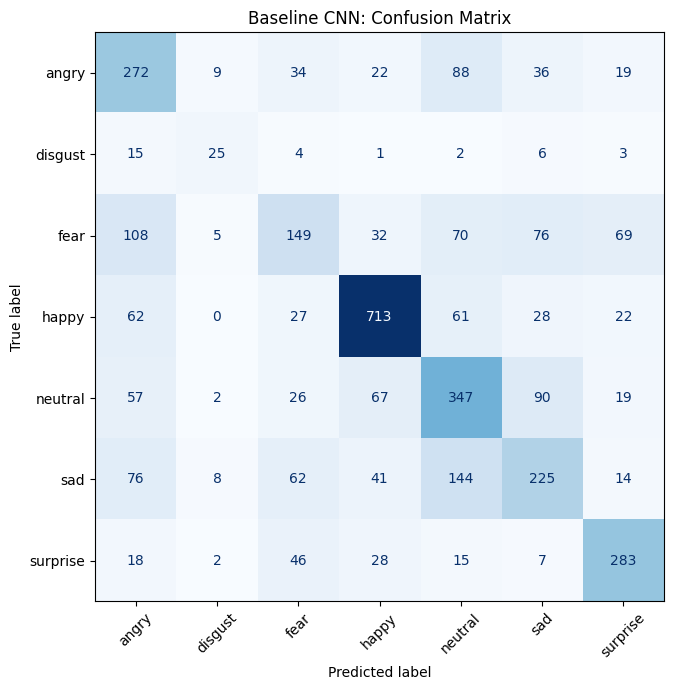

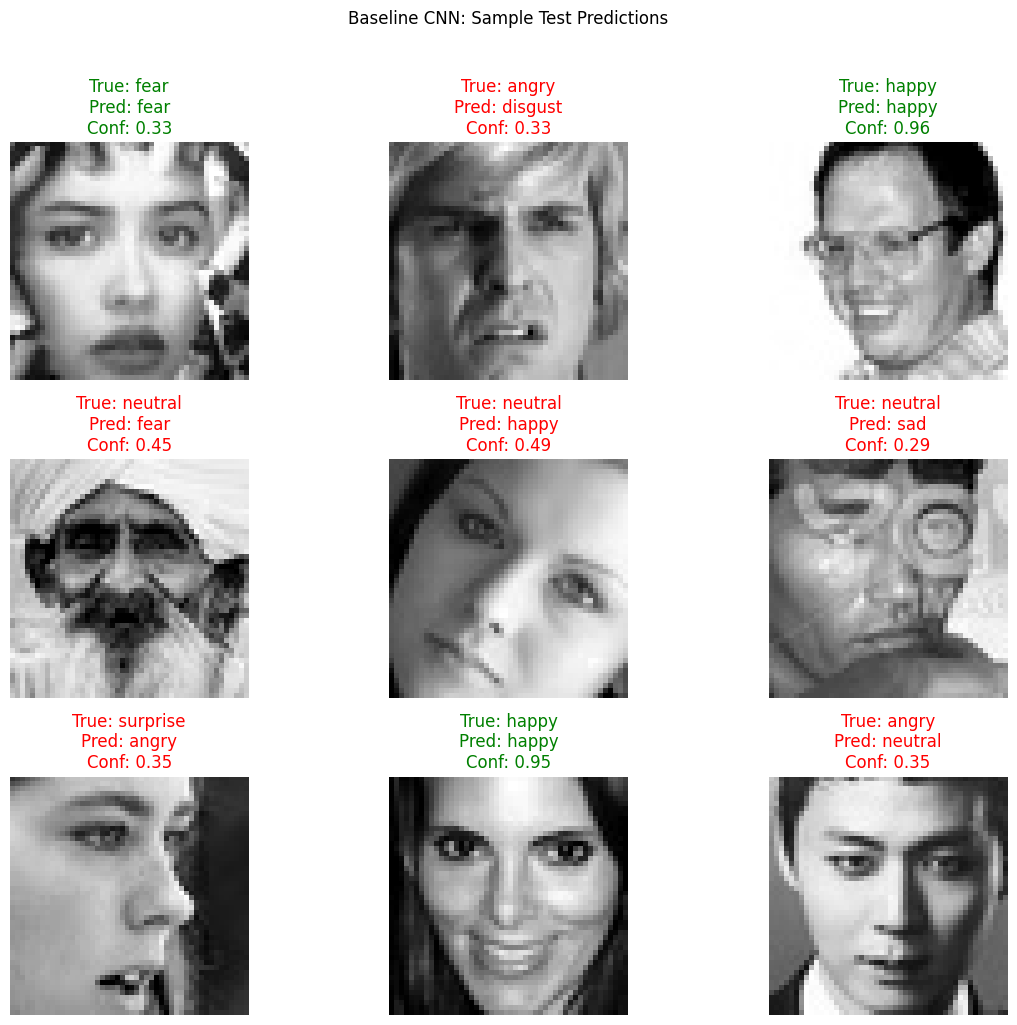

In [11]:
plot_history(baseline_history, "Baseline CNN")

baseline_metrics, baseline_y_true, baseline_y_pred, baseline_y_prob = evaluate_model(
    baseline_model, test_ds, class_names, "Baseline CNN"
)

plot_sample_predictions(
    baseline_model, test_ds, class_names,
    title="Baseline CNN: Sample Test Predictions"
)

## Deeper CNN with regularization


In [12]:
from tensorflow.keras.layers import BatchNormalization, Dropout

deeper_model = Sequential([
    data_augmentation,
    Rescaling(1./255, input_shape=(48, 48, 1)),
    #Conv layers
    # Block 1
    Conv2D(32, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Block 4
    Conv2D(256, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Flatten(),

    # Dense layers
    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(128, activation='relu'),

    Dense(64, activation='relu'),

    Dense(7, activation='softmax')
])

deeper_model.compile(optimizer='adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'])

deeper_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mild_data_augmentation          │ (1, 48, 48, 1)         │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (1, 48, 48, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (1, 48, 48, 32)        │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (1, 48, 48, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (1, 46, 46, 32)        │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (1, 23, 23, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (1, 23, 23, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (1, 23, 23, 64)        │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (1, 23, 23, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (1, 21, 21, 64)        │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (1, 10, 10, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (1, 10, 10, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (1, 10, 10, 128)       │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (1, 10, 10, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (1, 8, 8, 128)         │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (1, 4, 4, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (1, 4, 4, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (1, 4, 4, 256)         │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (1, 4, 4, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (1, 2, 2, 256)         │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (1, 1, 1, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (1, 1, 1, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,280,999 (4.89 MB)

 Trainable params: 1,280,039 (4.88 MB)

 Non-trainable params: 960 (3.75 KB)

In [13]:
#Train deeper model
DEEPER_EPOCHS = 60

start_time = time.time()
deeper_history = deeper_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=DEEPER_EPOCHS,
    class_weight=class_weights,
    callbacks=make_callbacks("deeper_cnn", monitor="val_loss", mode="min", patience=10),
    verbose=1
)
deeper_training_time = time.time() - start_time

print(f"Deeper model training time: {deeper_training_time:.2f} seconds")

Epoch 1/60
450/451 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.2062 - loss: 1.8622
Epoch 1: val_loss improved from None to 1.85257, saving model to deeper_cnn_best.keras

Epoch 1: finished saving model to deeper_cnn_best.keras
451/451 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - accuracy: 0.2306 - loss: 1.8064 - val_accuracy: 0.2583 - val_loss: 1.8526 - learning_rate: 0.0010
Epoch 2/60
450/451 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3047 - loss: 1.6971
Epoch 2: val_loss improved from 1.85257 to 1.68661, saving model to deeper_cnn_best.keras

Epoch 2: finished saving model to deeper_cnn_best.keras
451/451 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.3288 - loss: 1.6620 - val_accuracy: 0.3299 - val_loss: 1.6866 - learning_rate: 0.0010
Epoch 3/60
450/451 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3882 - loss: 1.5501
Epoch 3: val_loss improved from 1.68661 to 1.47923, saving model to deeper_cnn_best.keras

Epoch 3: finished saving model to deeper_cnn_best.keras
451/451 ━━━━━━━

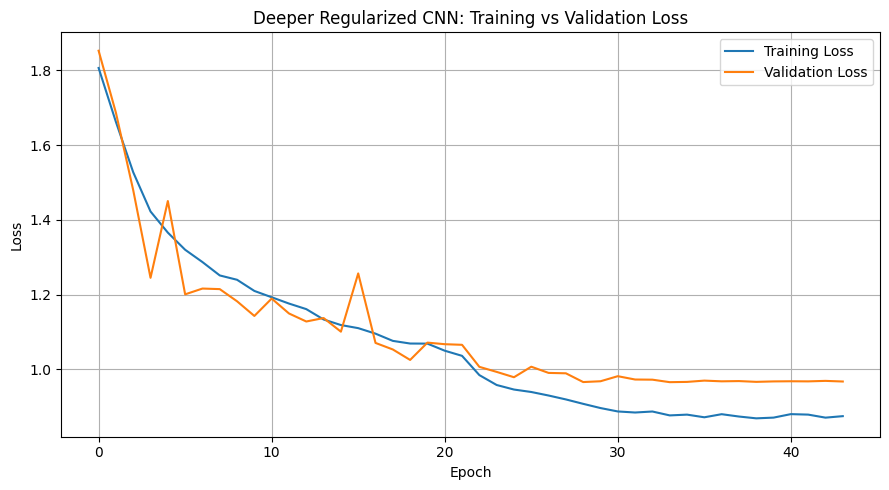

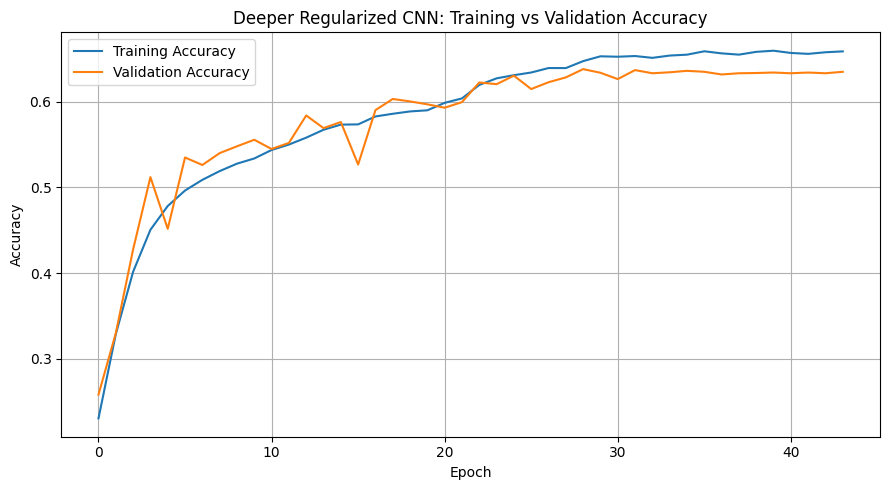


Deeper Regularized CNN Evaluation
------------------------------------------------------------
Test loss: 1.0104
Test accuracy: 0.6266
Weighted precision: 0.6295
Weighted recall: 0.6266
Weighted F1-score: 0.6234

Classification Report:
              precision    recall  f1-score   support

       angry       0.53      0.54      0.53       480
     disgust       0.50      0.55      0.53        56
        fear       0.49      0.34      0.40       509
       happy       0.88      0.83      0.85       913
     neutral       0.53      0.71      0.60       608
         sad       0.51      0.47      0.49       570
    surprise       0.71      0.75      0.73       399

    accuracy                           0.63      3535
   macro avg       0.59      0.60      0.59      3535
weighted avg       0.63      0.63      0.62      3535



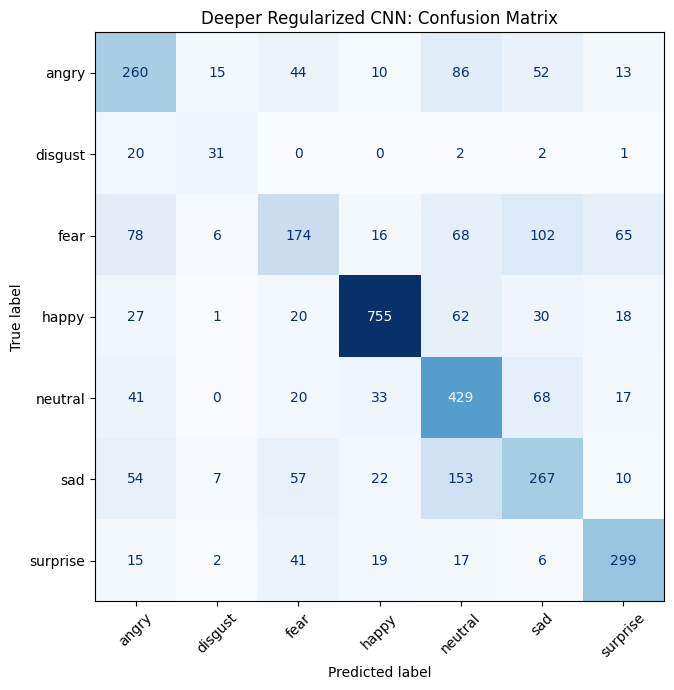

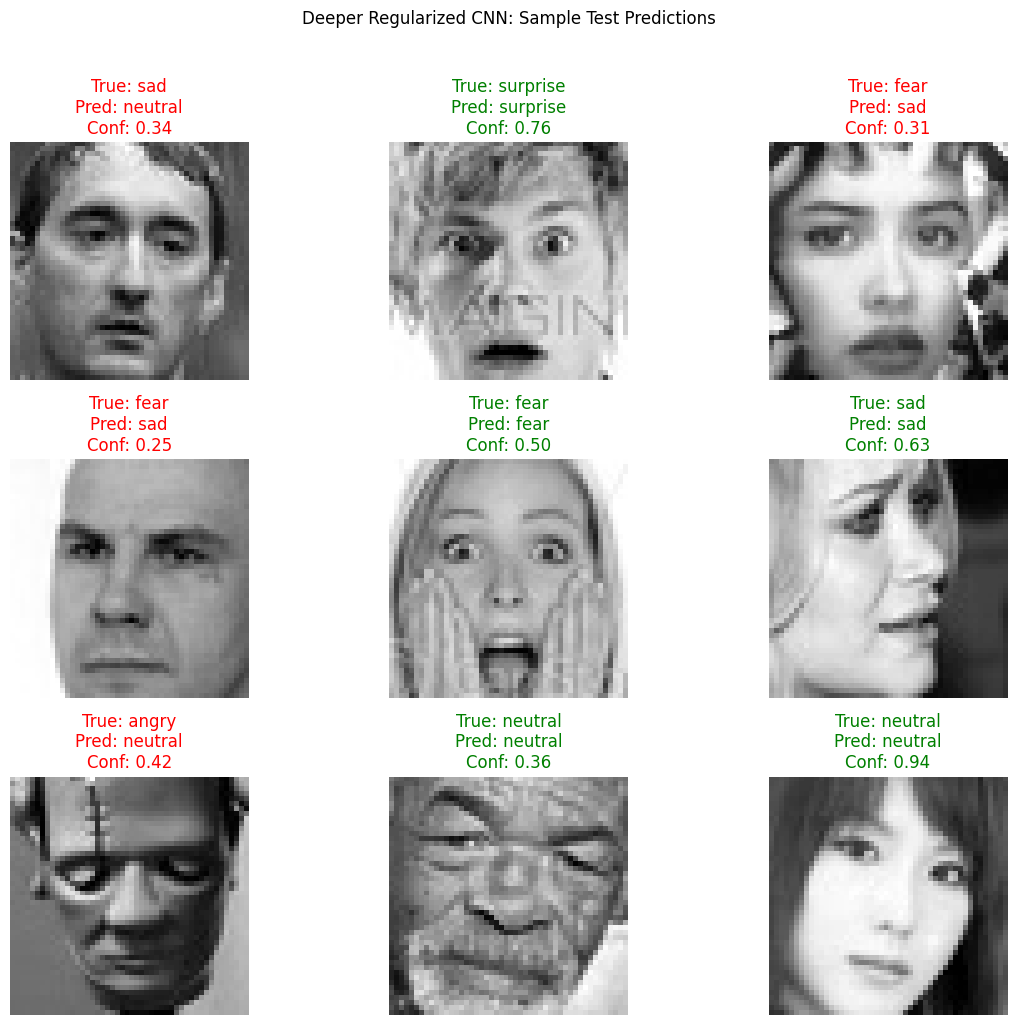

In [14]:
plot_history(deeper_history, "Deeper Regularized CNN")

deeper_metrics, deeper_y_true, deeper_y_pred, deeper_y_prob = evaluate_model(
    deeper_model, test_ds, class_names, "Deeper Regularized CNN"
)

plot_sample_predictions(
    deeper_model, test_ds, class_names,
    title="Deeper Regularized CNN: Sample Test Predictions"
)

## Optimizer analysis: SGD vs Adam


Epoch 1/25
450/451 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.2139 - loss: 1.9617
Epoch 1: val_loss improved from None to 1.94384, saving model to deeper_sgd_best.keras

Epoch 1: finished saving model to deeper_sgd_best.keras
451/451 ━━━━━━━━━━━━━━━━━━━━ 24s 39ms/step - accuracy: 0.2247 - loss: 1.9325 - val_accuracy: 0.2583 - val_loss: 1.9438 - learning_rate: 0.0100
Epoch 2/25
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.2516 - loss: 1.8985
Epoch 2: val_loss improved from 1.94384 to 1.85829, saving model to deeper_sgd_best.keras

Epoch 2: finished saving model to deeper_sgd_best.keras
451/451 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.2589 - loss: 1.8852 - val_accuracy: 0.2948 - val_loss: 1.8583 - learning_rate: 0.0100
Epoch 3/25
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.2860 - loss: 1.8203
Epoch 3: val_loss improved from 1.85829 to 1.83124, saving model to deeper_sgd_best.keras

Epoch 3: finished saving model to deeper_sgd_best.keras
451/451 ━━━━━━━

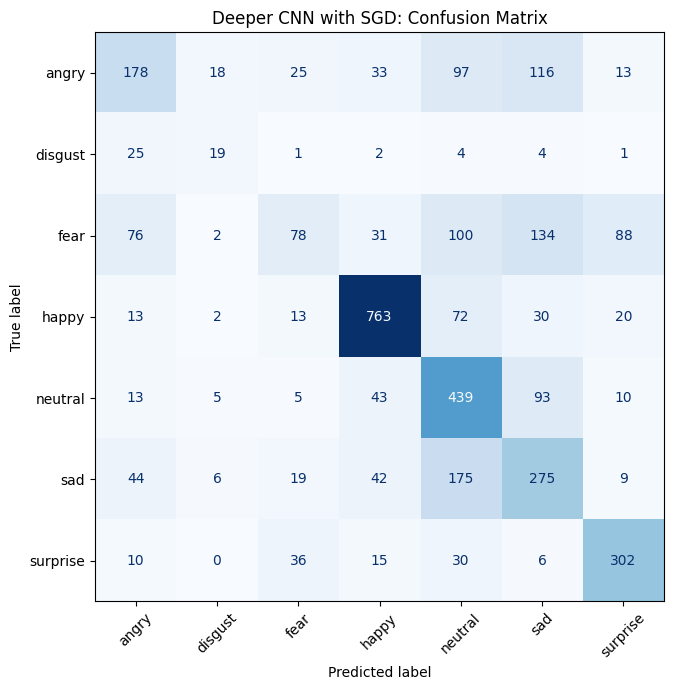

Epoch 1/25
450/451 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.2140 - loss: 1.9376
Epoch 1: val_loss improved from None to 1.88647, saving model to deeper_adam_best.keras

Epoch 1: finished saving model to deeper_adam_best.keras
451/451 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - accuracy: 0.2353 - loss: 1.9125 - val_accuracy: 0.2809 - val_loss: 1.8865 - learning_rate: 0.0010
Epoch 2/25
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.2936 - loss: 1.7987
Epoch 2: val_loss did not improve from 1.88647
451/451 ━━━━━━━━━━━━━━━━━━━━ 18s 41ms/step - accuracy: 0.3128 - loss: 1.7684 - val_accuracy: 0.3044 - val_loss: 2.0476 - learning_rate: 0.0010
Epoch 3/25
450/451 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.3781 - loss: 1.6567
Epoch 3: val_loss did not improve from 1.88647
451/451 ━━━━━━━━━━━━━━━━━━━━ 19s 42ms/step - accuracy: 0.3898 - loss: 1.6343 - val_accuracy: 0.2886 - val_loss: 2.5221 - learning_rate: 0.0010
Epoch 4/25
450/451 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.436

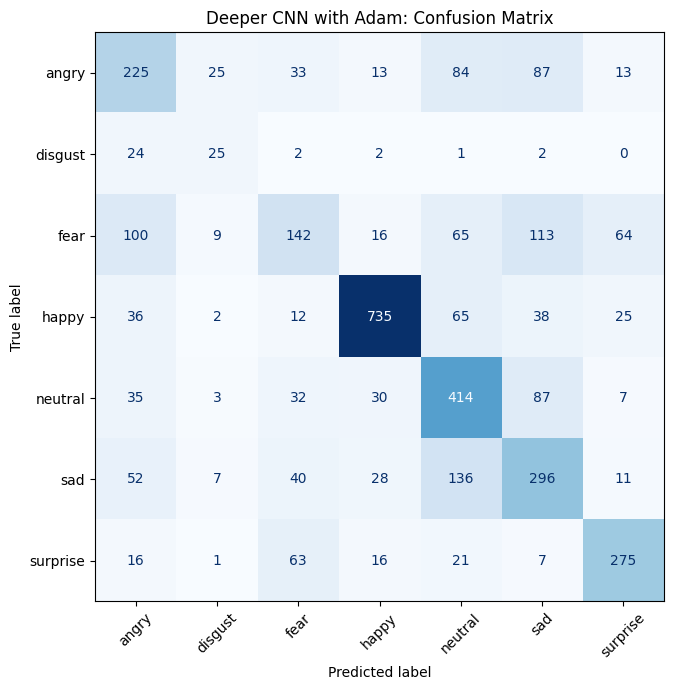

,Model,Test Loss,Test Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Training Time (seconds)
0,Deeper CNN with SGD,1.205801,0.581047,0.575366,0.581047,0.562109,437.919368
1,Deeper CNN with Adam,1.148955,0.597454,0.602136,0.597454,0.594874,484.660213


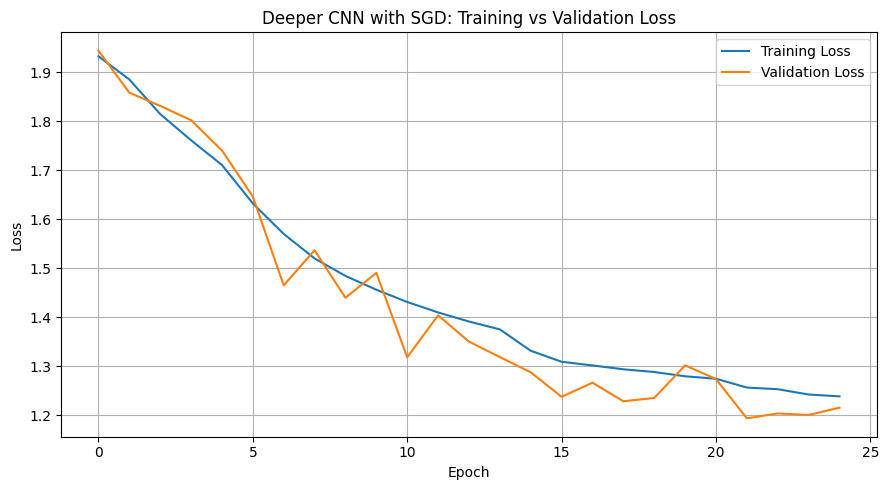

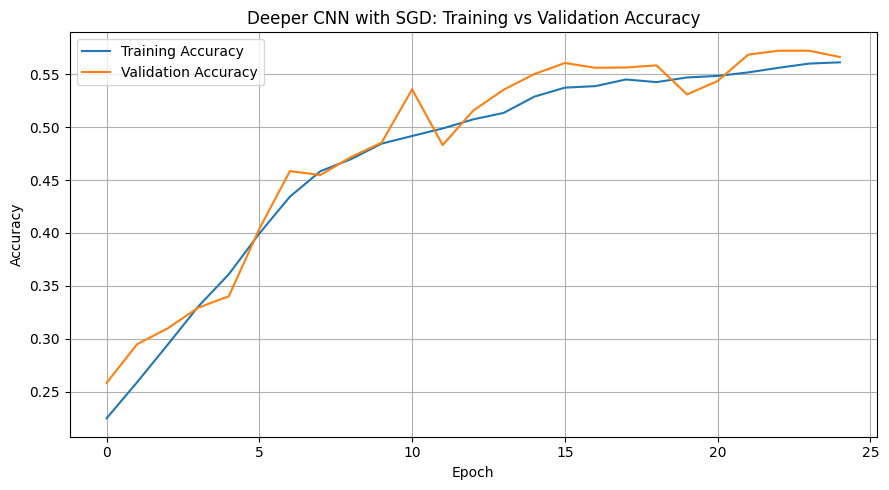

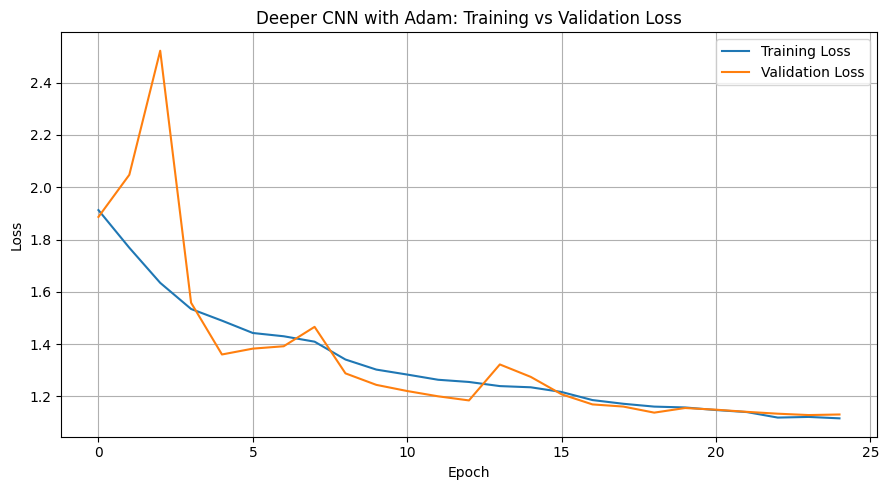

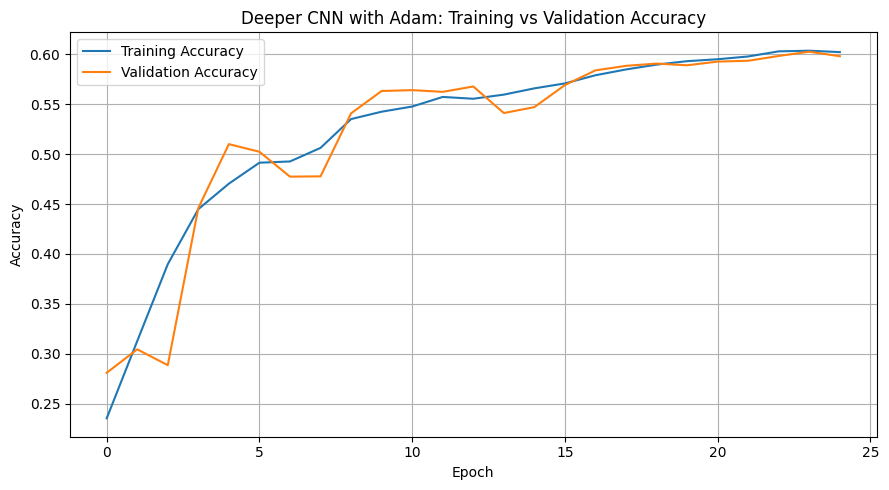

In [15]:
# Optimizer Comparison
OPTIMIZER_EPOCHS = 25

optimizer_results = []

def conv_bn_relu(x, filters, kernel_size=(3, 3), l2_strength=1e-4):
    x = Conv2D(
        filters,
        kernel_size,
        padding="same",
        use_bias=False,
        kernel_regularizer=regularizers.l2(l2_strength)
    )(x)
    x = BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    return x

def build_deeper_model(optimizer=None, include_dropout=True, include_batchnorm=True):
    inputs = layers.Input(shape=(48, 48, 1))
    x = data_augmentation(inputs)
    x = Rescaling(1./255)(x)

    # Block 1: 2 convolutional layers
    if include_batchnorm:
        x = conv_bn_relu(x, 32)
        x = conv_bn_relu(x, 32)
    else:
        x = Conv2D(32, (3,3), activation="relu", padding="same")(x)
        x = Conv2D(32, (3,3), activation="relu", padding="same")(x)
    x = MaxPooling2D((2, 2))(x)
    if include_dropout:
        x = Dropout(0.20)(x)

    # Block 2: 2 convolutional layers
    if include_batchnorm:
        x = conv_bn_relu(x, 64)
        x = conv_bn_relu(x, 64)
    else:
        x = Conv2D(64, (3,3), activation="relu", padding="same")(x)
        x = Conv2D(64, (3,3), activation="relu", padding="same")(x)
    x = MaxPooling2D((2, 2))(x)
    if include_dropout:
        x = Dropout(0.25)(x)

    # Block 3: 2 convolutional layers
    if include_batchnorm:
        x = conv_bn_relu(x, 128)
        x = conv_bn_relu(x, 128)
    else:
        x = Conv2D(128, (3,3), activation="relu", padding="same")(x)
        x = Conv2D(128, (3,3), activation="relu", padding="same")(x)
    x = MaxPooling2D((2, 2))(x)
    if include_dropout:
        x = Dropout(0.30)(x)

    # Block 4: 2 convolutional layers
    if include_batchnorm:
        x = conv_bn_relu(x, 256)
        x = conv_bn_relu(x, 256)
    else:
        x = Conv2D(256, (3,3), activation="relu", padding="same")(x)
        x = Conv2D(256, (3,3), activation="relu", padding="same")(x)
    x = MaxPooling2D((2, 2))(x)
    if include_dropout:
        x = Dropout(0.35)(x)

    x = GlobalAveragePooling2D()(x)

    x = Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
    if include_dropout:
        x = Dropout(0.45)(x)
    x = Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
    if include_dropout:
        x = Dropout(0.30)(x)
    x = Dense(64, activation="relu")(x)

    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs, name="deeper_regularized_cnn")

    if optimizer is None:
        optimizer = Adam(learning_rate=1e-3)

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# SGD with momentum
sgd_model = build_deeper_model(
    optimizer=SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
)

start_time = time.time()
sgd_history = sgd_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=OPTIMIZER_EPOCHS,
    class_weight=class_weights,
    callbacks=make_callbacks("deeper_sgd", monitor="val_loss", mode="min", patience=6),
    verbose=1
)
sgd_training_time = time.time() - start_time

sgd_metrics, _, _, _ = evaluate_model(sgd_model, test_ds, class_names, "Deeper CNN with SGD")
sgd_metrics["Training Time (seconds)"] = sgd_training_time
optimizer_results.append(sgd_metrics)

# Adam
adam_model = build_deeper_model(
    optimizer=Adam(learning_rate=1e-3)
)

start_time = time.time()
adam_history = adam_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=OPTIMIZER_EPOCHS,
    class_weight=class_weights,
    callbacks=make_callbacks("deeper_adam", monitor="val_loss", mode="min", patience=6),
    verbose=1
)
adam_training_time = time.time() - start_time

adam_metrics, _, _, _ = evaluate_model(adam_model, test_ds, class_names, "Deeper CNN with Adam")
adam_metrics["Training Time (seconds)"] = adam_training_time
optimizer_results.append(adam_metrics)

optimizer_df = pd.DataFrame(optimizer_results)
display(optimizer_df)

plot_history(sgd_history, "Deeper CNN with SGD")
plot_history(adam_history, "Deeper CNN with Adam")

## Ablation study: removing dropout


Model: "deeper_regularized_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mild_data_augmentation          │ (None, 48, 48, 1)      │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 48, 48, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 48, 48, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 24, 24, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 24, 24, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_19 (Activation)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 12, 12, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 12, 12, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 12, 12, 128)    │           51

 Total params: 1,281,959 (4.89 MB)

 Trainable params: 1,280,039 (4.88 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/25
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.2553 - loss: 1.8900
Epoch 1: val_loss improved from None to 2.21586, saving model to ablation_no_dropout_best.keras

Epoch 1: finished saving model to ablation_no_dropout_best.keras
451/451 ━━━━━━━━━━━━━━━━━━━━ 25s 41ms/step - accuracy: 0.2935 - loss: 1.8176 - val_accuracy: 0.2985 - val_loss: 2.2159 - learning_rate: 0.0010
Epoch 2/25
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.4278 - loss: 1.5740
Epoch 2: val_loss improved from 2.21586 to 1.84974, saving model to ablation_no_dropout_best.keras

Epoch 2: finished saving model to ablation_no_dropout_best.keras
451/451 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - accuracy: 0.4492 - loss: 1.5252 - val_accuracy: 0.3792 - val_loss: 1.8497 - learning_rate: 0.0010
Epoch 3/25
450/451 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4896 - loss: 1.4226
Epoch 3: val_loss improved from 1.84974 to 1.57756, saving model to ablation_no_dropout_best.keras

Epoch 3: finished saving m

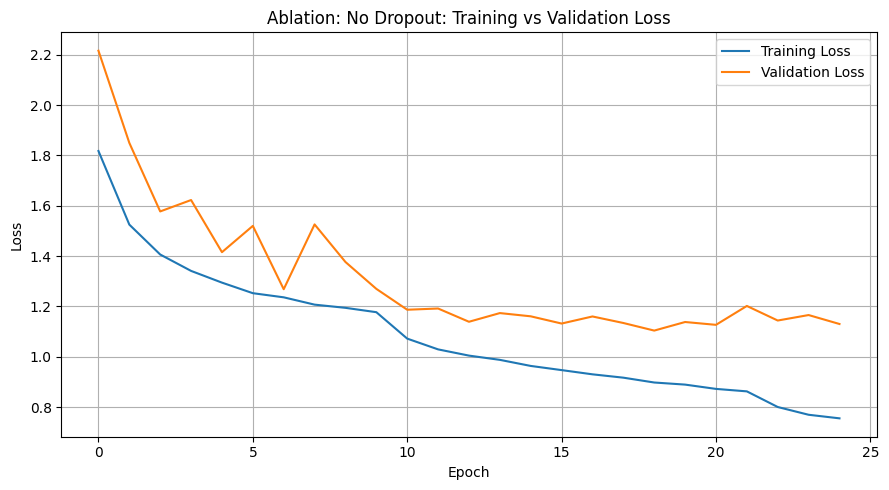

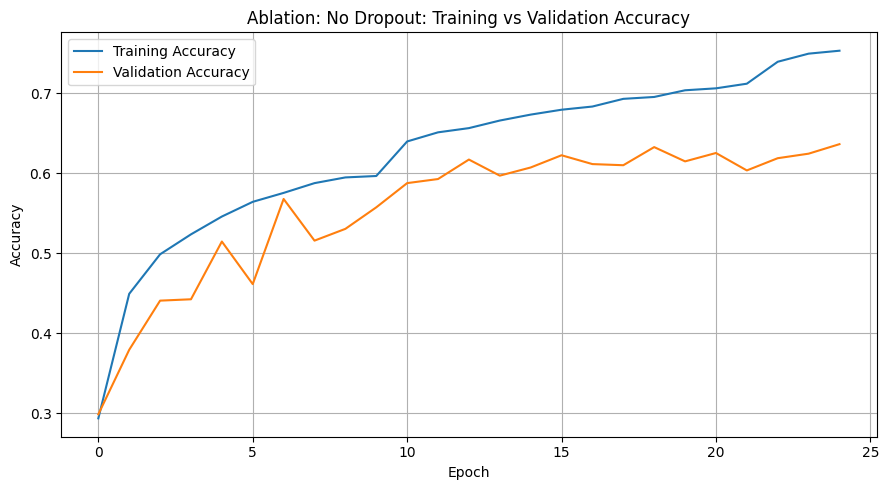


Ablation: Deeper CNN without Dropout Evaluation
------------------------------------------------------------
Test loss: 1.1344
Test accuracy: 0.6368
Weighted precision: 0.6412
Weighted recall: 0.6368
Weighted F1-score: 0.6279

Classification Report:
              precision    recall  f1-score   support

       angry       0.61      0.49      0.54       480
     disgust       0.50      0.66      0.57        56
        fear       0.58      0.29      0.38       509
       happy       0.83      0.87      0.85       913
     neutral       0.60      0.60      0.60       608
         sad       0.46      0.64      0.53       570
    surprise       0.68      0.78      0.73       399

    accuracy                           0.64      3535
   macro avg       0.61      0.62      0.60      3535
weighted avg       0.64      0.64      0.63      3535



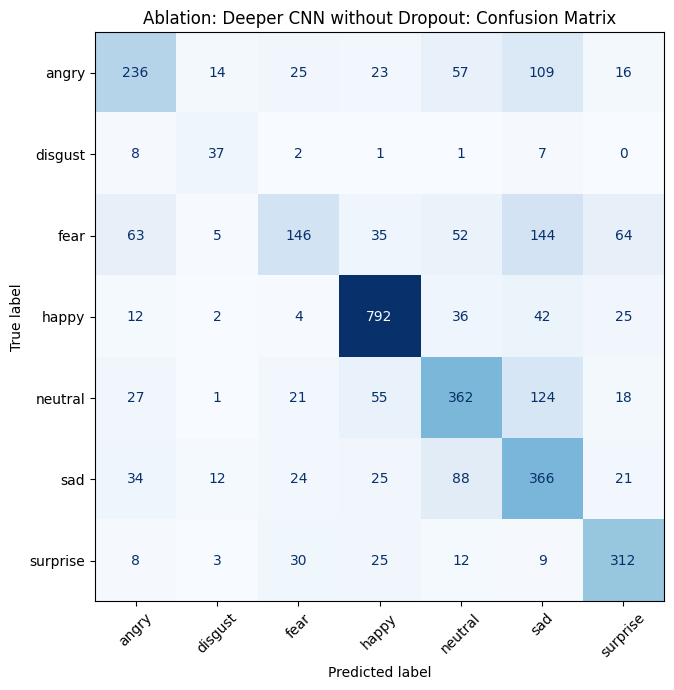

In [16]:

ablation_no_dropout_model = build_deeper_model(
    optimizer=Adam(learning_rate=1e-3),
    include_dropout=False,
    include_batchnorm=True
)

ablation_no_dropout_model.summary()

ABLATION_EPOCHS = 25

start_time = time.time()
ablation_history = ablation_no_dropout_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=ABLATION_EPOCHS,
    class_weight=class_weights,
    callbacks=make_callbacks("ablation_no_dropout", monitor="val_loss", mode="min", patience=6),
    verbose=1
)
ablation_training_time = time.time() - start_time

plot_history(ablation_history, "Ablation: No Dropout")

ablation_metrics, _, _, _ = evaluate_model(
    ablation_no_dropout_model,
    test_ds,
    class_names,
    "Ablation: Deeper CNN without Dropout"
)
ablation_metrics["Training Time (seconds)"] = ablation_training_time

# Part B: Transfer learning

In [17]:
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input

TRANSFER_SIZE = (96, 96)
TRANSFER_BATCH_SIZE = 64

transfer_train_raw = tf.keras.utils.image_dataset_from_directory(
    train_data_dir,
    image_size=TRANSFER_SIZE,
    color_mode="rgb",
    batch_size=TRANSFER_BATCH_SIZE,
    label_mode="int",
    shuffle=True,
    seed=SEED
)

transfer_val_raw = tf.keras.utils.image_dataset_from_directory(
    validation_data_dir,
    image_size=TRANSFER_SIZE,
    color_mode="rgb",
    batch_size=TRANSFER_BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

transfer_test_raw = tf.keras.utils.image_dataset_from_directory(
    test_data_dir,
    image_size=TRANSFER_SIZE,
    color_mode="rgb",
    batch_size=TRANSFER_BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

transfer_train_ds = transfer_train_raw.cache().shuffle(2000, seed=SEED).prefetch(AUTOTUNE)
transfer_val_ds = transfer_val_raw.cache().prefetch(AUTOTUNE)
transfer_test_ds = transfer_test_raw.cache().prefetch(AUTOTUNE)

Found 28821 files belonging to 7 classes.
Found 3531 files belonging to 7 classes.
Found 3535 files belonging to 7 classes.


In [18]:
# Build Transfer learning model
transfer_augmentation = Sequential([
    layers.RandomFlip("horizontal", seed=SEED),
    layers.RandomRotation(0.03, seed=SEED),
    layers.RandomZoom(0.06, seed=SEED),
    layers.RandomContrast(0.10, seed=SEED),
], name="transfer_augmentation")

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(96, 96, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(96, 96, 3))
x = transfer_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.40)(x)
x = Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
x = Dropout(0.30)(x)
outputs = Dense(num_classes, activation="softmax")(x)

transfer_model = Model(inputs, outputs, name="mobilenetv2_feature_extraction")

transfer_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_feature_extraction"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transfer_augmentation           │ (None, 96, 96, 3)      │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/20
450/451 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2900 - loss: 1.8824
Epoch 1: val_loss improved from None to 1.60867, saving model to transfer_feature_extraction_best.keras

Epoch 1: finished saving model to transfer_feature_extraction_best.keras
451/451 ━━━━━━━━━━━━━━━━━━━━ 29s 35ms/step - accuracy: 0.3268 - loss: 1.7255 - val_accuracy: 0.4135 - val_loss: 1.6087 - learning_rate: 0.0010
Epoch 2/20
450/451 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3681 - loss: 1.6200
Epoch 2: val_loss improved from 1.60867 to 1.51439, saving model to transfer_feature_extraction_best.keras

Epoch 2: finished saving model to transfer_feature_extraction_best.keras
451/451 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.3746 - loss: 1.6029 - val_accuracy: 0.4441 - val_loss: 1.5144 - learning_rate: 0.0010
Epoch 3/20
450/451 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.3949 - loss: 1.5524
Epoch 3: val_loss improved from 1.51439 to 1.51333, saving model to transfer_feature_extractio

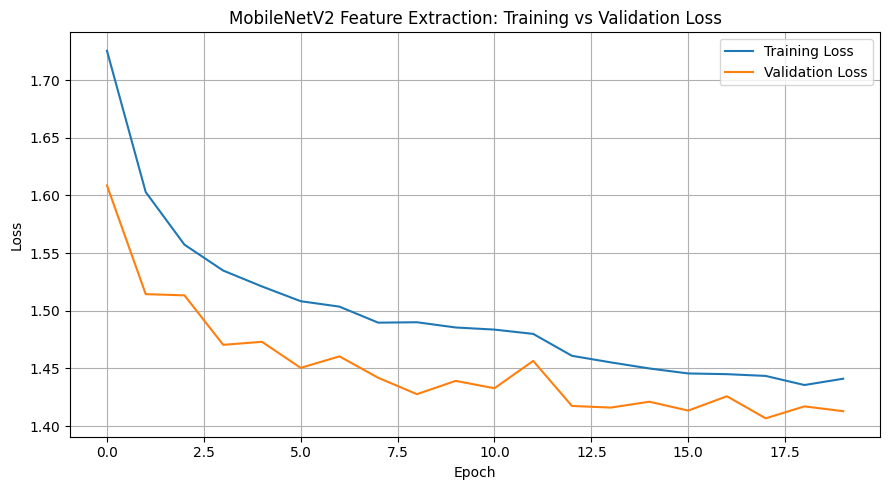

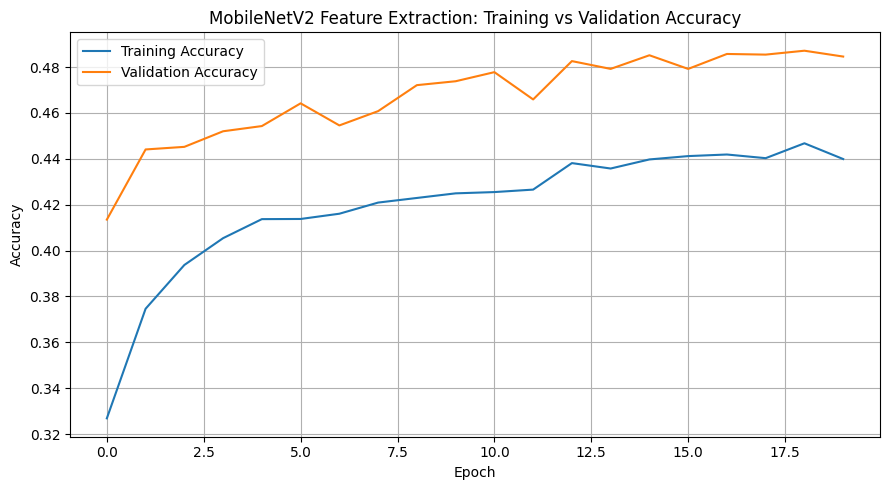

In [19]:
# Feature Extraction
FEATURE_EPOCHS = 20

start_time = time.time()
transfer_history = transfer_model.fit(
    transfer_train_ds,
    validation_data=transfer_val_ds,
    epochs=FEATURE_EPOCHS,
    class_weight=class_weights,
    callbacks=make_callbacks("transfer_feature_extraction", monitor="val_loss", mode="min", patience=6),
    verbose=1
)
transfer_feature_time = time.time() - start_time

print(f"Transfer feature extraction training time: {transfer_feature_time:.2f} seconds")
plot_history(transfer_history, "MobileNetV2 Feature Extraction")

Total base model layers: 154
Fine-tuning from layer index: 115
Trainable layers in full model: 8
Epoch 1/20
450/451 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.4514 - loss: 1.4317
Epoch 1: val_loss improved from None to 1.36194, saving model to transfer_fine_tuned_best.keras

Epoch 1: finished saving model to transfer_fine_tuned_best.keras
451/451 ━━━━━━━━━━━━━━━━━━━━ 29s 48ms/step - accuracy: 0.4557 - loss: 1.4151 - val_accuracy: 0.5033 - val_loss: 1.3619 - learning_rate: 1.0000e-05
Epoch 2/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.4752 - loss: 1.3782
Epoch 2: val_loss improved from 1.36194 to 1.33181, saving model to transfer_fine_tuned_best.keras

Epoch 2: finished saving model to transfer_fine_tuned_best.keras
451/451 ━━━━━━━━━━━━━━━━━━━━ 20s 45ms/step - accuracy: 0.4807 - loss: 1.3623 - val_accuracy: 0.5120 - val_loss: 1.3318 - learning_rate: 1.0000e-05
Epoch 3/20
450/451 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.4863 - loss: 1.3420
Epoch 3: val_loss imp

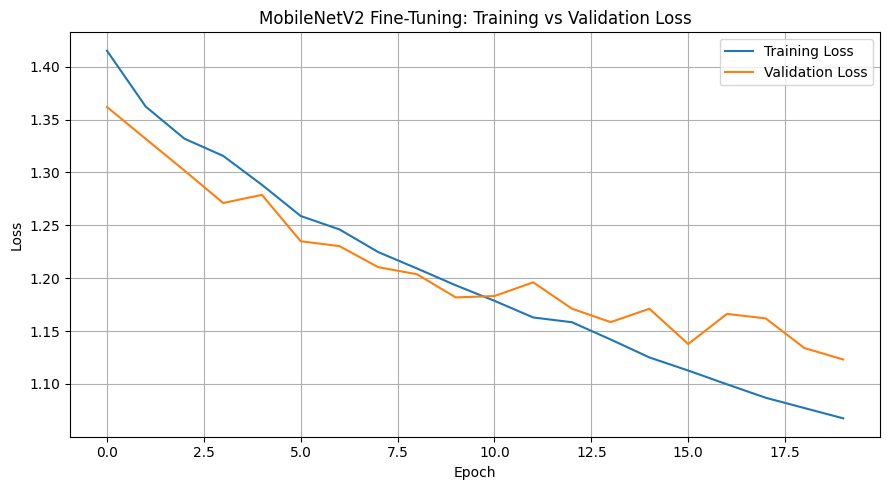

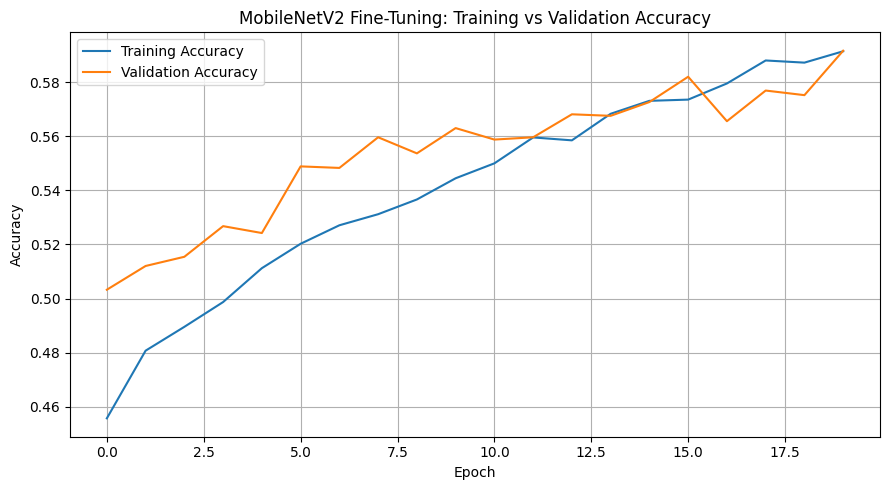

In [20]:
# Fine Tuning
base_model.trainable = True

fine_tune_at = int(len(base_model.layers) * 0.75)

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

for layer in base_model.layers[fine_tune_at:]:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False

transfer_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Total base model layers:", len(base_model.layers))
print("Fine-tuning from layer index:", fine_tune_at)
print("Trainable layers in full model:", sum(layer.trainable for layer in transfer_model.layers))

FINE_TUNE_EPOCHS = 20

start_time = time.time()
fine_tune_history = transfer_model.fit(
    transfer_train_ds,
    validation_data=transfer_val_ds,
    epochs=FINE_TUNE_EPOCHS,
    class_weight=class_weights,
    callbacks=make_callbacks("transfer_fine_tuned", monitor="val_loss", mode="min", patience=6),
    verbose=1
)
transfer_fine_tune_time = time.time() - start_time

print(f"Transfer fine-tuning time: {transfer_fine_tune_time:.2f} seconds")
plot_history(fine_tune_history, "MobileNetV2 Fine-Tuning")


MobileNetV2 Transfer Learning Evaluation
------------------------------------------------------------
Test loss: 1.1528
Test accuracy: 0.5850
Weighted precision: 0.5836
Weighted recall: 0.5850
Weighted F1-score: 0.5808

Classification Report:
              precision    recall  f1-score   support

       angry       0.49      0.51      0.50       480
     disgust       0.62      0.46      0.53        56
        fear       0.45      0.30      0.36       509
       happy       0.79      0.78      0.78       913
     neutral       0.49      0.61      0.55       608
         sad       0.47      0.48      0.47       570
    surprise       0.70      0.72      0.71       399

    accuracy                           0.59      3535
   macro avg       0.57      0.55      0.56      3535
weighted avg       0.58      0.59      0.58      3535



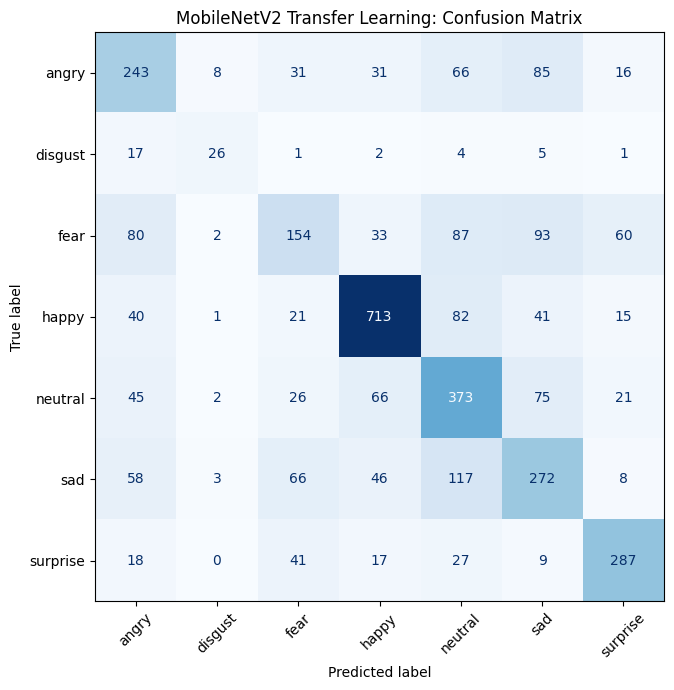

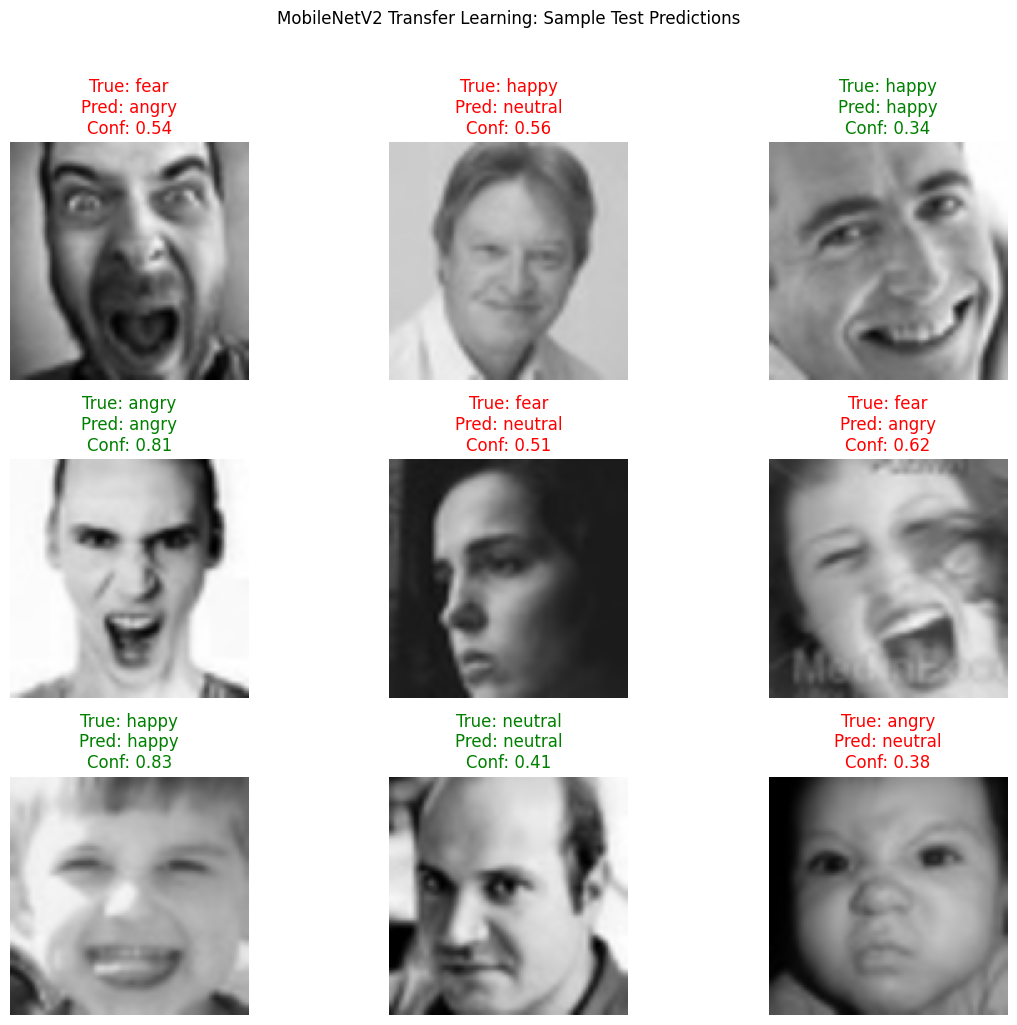

In [25]:
# Evaluating transfer learning model
transfer_metrics, transfer_y_true, transfer_y_pred, transfer_y_prob = evaluate_model(
    transfer_model,
    transfer_test_ds,
    class_names,
    "MobileNetV2 Transfer Learning"
)

transfer_metrics["Training Time (seconds)"] = transfer_feature_time + transfer_fine_tune_time
plot_sample_predictions(
    transfer_model,
    transfer_test_ds,
    class_names,
    title="MobileNetV2 Transfer Learning: Sample Test Predictions"
)


# Final comparative analysis

This section compares all major models using the same evaluation metrics. Use this table directly in the report, but replace the numbers after running the notebook.

,Model,Test Loss,Test Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Training Time (seconds)
0,Baseline CNN,1.1491,0.5697,0.5679,0.5697,0.5645,202.2484
1,Deeper Regularized CNN,1.0104,0.6266,0.6295,0.6266,0.6234,644.6396
2,Deeper CNN with SGD,1.2058,0.5810,0.5754,0.5810,0.5621,437.9194
3,Deeper CNN with Adam,1.1490,0.5975,0.6021,0.5975,0.5949,484.6602
4,Ablation: Deeper CNN without Dropout,1.1344,0.6368,0.6412,0.6368,0.6279,455.3235
5,MobileNetV2 Transfer Learning,1.1528,0.5850,0.5836,0.5850,0.5808,705.8736


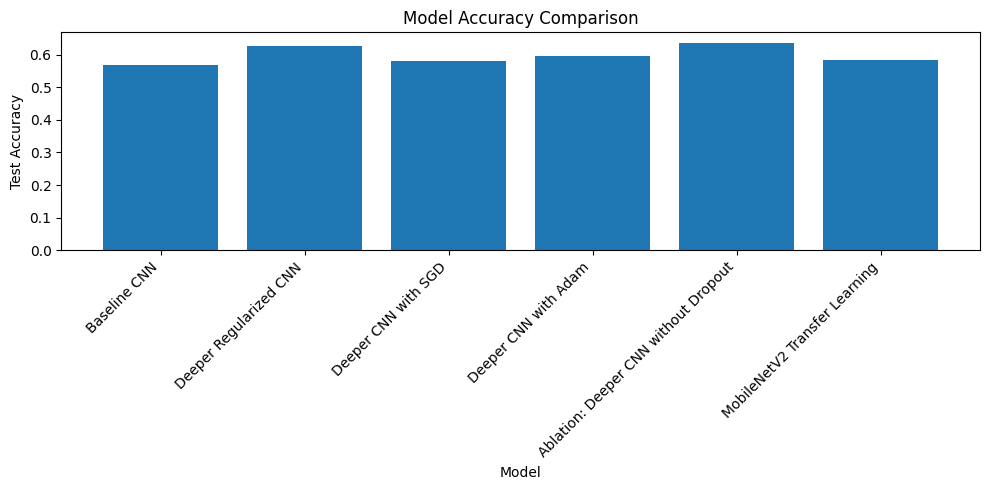

In [22]:
# Compare all models
baseline_metrics["Training Time (seconds)"] = baseline_training_time
deeper_metrics["Training Time (seconds)"] = deeper_training_time

comparison_df = pd.DataFrame([
    baseline_metrics,
    deeper_metrics,
    sgd_metrics,
    adam_metrics,
    ablation_metrics,
    transfer_metrics
])

numeric_cols = comparison_df.select_dtypes(include=[np.number]).columns
comparison_df[numeric_cols] = comparison_df[numeric_cols].round(4)

display(comparison_df)

plt.figure(figsize=(10, 5))
plt.bar(comparison_df["Model"], comparison_df["Test Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Best model based on test accuracy: Ablation: Deeper CNN without Dropout
Number of misclassified examples: 1320


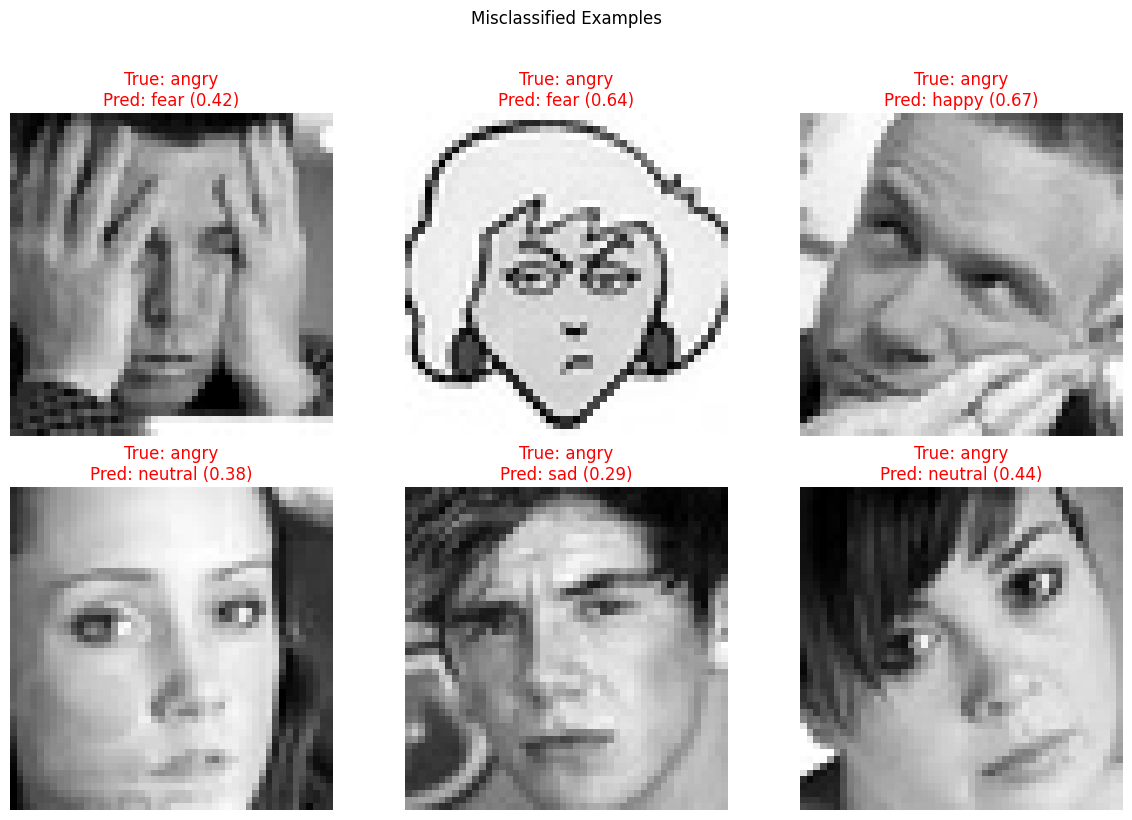

In [23]:
# =Misclassification analysis for the best model
best_row = comparison_df.sort_values("Test Accuracy", ascending=False).iloc[0]
best_model_name = best_row["Model"]
print("Best model based on test accuracy:", best_model_name)

if best_model_name == "MobileNetV2 Transfer Learning":
    best_model = transfer_model
    best_dataset = transfer_test_ds
else:
    best_model = deeper_model
    best_dataset = test_ds

all_images = []
all_true = []
for images, labels in best_dataset:
    all_images.append(images.numpy())
    all_true.append(labels.numpy())

all_images = np.concatenate(all_images, axis=0)
all_true = np.concatenate(all_true, axis=0)

all_probs = best_model.predict(best_dataset, verbose=0)
all_pred = np.argmax(all_probs, axis=1)

wrong_indices = np.where(all_true != all_pred)[0]
print("Number of misclassified examples:", len(wrong_indices))

plt.figure(figsize=(12, 8))
for plot_i, idx in enumerate(wrong_indices[:6], start=1):
    plt.subplot(2, 3, plot_i)
    img = all_images[idx]

    if img.shape[-1] == 1:
        plt.imshow(np.squeeze(img), cmap="gray")
    else:
        # Transfer dataset images are RGB and still in 0-255 range before model preprocessing.
        plt.imshow(img.astype("uint8"))

    true_label = class_names[int(all_true[idx])]
    pred_label = class_names[int(all_pred[idx])]
    confidence = np.max(all_probs[idx])

    plt.title(f"True: {true_label}\nPred: {pred_label} ({confidence:.2f})", color="red")
    plt.axis("off")

plt.suptitle("Misclassified Examples", y=1.02)
plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# 22. Save final trained models
# ============================================================
SAVE_DIR = "/content/drive/MyDrive/college/sem6/AI&ML/Assessment/Vision Task/improved_models"
os.makedirs(SAVE_DIR, exist_ok=True)

baseline_model.save(os.path.join(SAVE_DIR, "baseline_cnn_improved.keras"))
deeper_model.save(os.path.join(SAVE_DIR, "deeper_regularized_cnn.keras"))
transfer_model.save(os.path.join(SAVE_DIR, "mobilenetv2_transfer_finetuned.keras"))

comparison_df.to_csv(os.path.join(SAVE_DIR, "model_comparison_results.csv"), index=False)

print("Saved models and comparison table to:", SAVE_DIR)

Saved models and comparison table to: /content/drive/MyDrive/college/sem6/AI&ML/Assessment/Vision Task/improved_models
